<a href="https://colab.research.google.com/github/Ashishpathak78/DL_practice/blob/main/DL_Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training...
Epoch [1/2], Loss: 0.1444
Epoch [2/2], Loss: 0.3231
True Label: 8
Predicted: 8


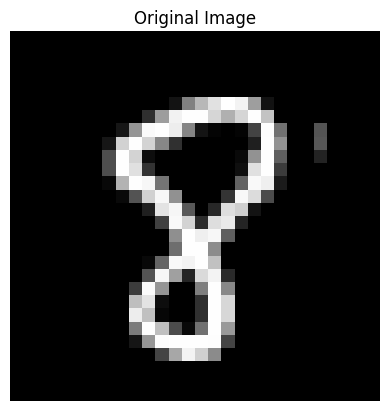

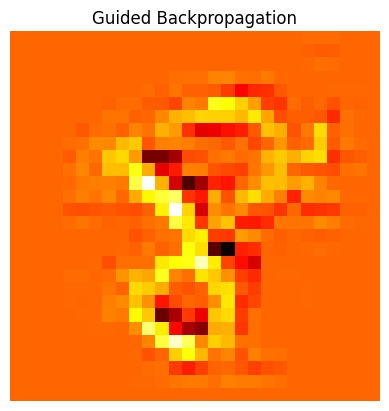

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1. DATASET
# ----------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=1, shuffle=True)

# ----------------------------
# 2. MODEL
# ----------------------------
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3)      # 28 → 26
        self.relu1 = nn.ReLU()
        self.pool = nn.MaxPool2d(2,2)        # 26 → 13
        self.fc = nn.Linear(8*13*13, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = CNN().to(device)

# ----------------------------
# 3. TRAIN (IMPORTANT)
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Training...")
for epoch in range(2):  # keep small for demo
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/2], Loss: {loss.item():.4f}")

# ----------------------------
# 4. GUIDED BACKPROP SETUP
# ----------------------------

# Forward hook to store activations
forward_activations = {}

def forward_hook(module, input, output):
    forward_activations[module] = output

# Backward hook (guided rule)
def backward_hook(module, grad_input, grad_output):
    activation = forward_activations[module]

    guided_grad = grad_input[0]

    guided_grad = torch.clamp(guided_grad, min=0.0)
    guided_grad = guided_grad * (activation > 0).float()

    return (guided_grad,)

# Register hooks
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.register_forward_hook(forward_hook)
        module.register_full_backward_hook(backward_hook)

# ----------------------------
# 5. GET SAMPLE
# ----------------------------
data_iter = iter(test_loader)
image, label = next(data_iter)

image = image.to(device)
image.requires_grad = True

# ----------------------------
# 6. FORWARD PASS
# ----------------------------
output = model(image)
pred_class = output.argmax()

print("True Label:", label.item())
print("Predicted:", pred_class.item())

# ----------------------------
# 7. BACKWARD PASS
# ----------------------------
model.zero_grad()

one_hot = torch.zeros_like(output)
one_hot[0][pred_class] = 1

output.backward(gradient=one_hot)

# ----------------------------
# 8. GET GUIDED GRADIENT
# ----------------------------
guided_grad = image.grad.detach().cpu()

# ----------------------------
# 9. VISUALIZATION
# ----------------------------

# Original Image
plt.imshow(image.detach().cpu()[0][0], cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Guided Backprop
plt.imshow(guided_grad[0][0], cmap='hot')
plt.title("Guided Backpropagation")
plt.axis('off')
plt.show()